In [3]:
from brian2 import *
from dataclasses import dataclass, field
from typing import Dict, Optional, List, Callable
import numpy as np
import pandas as pd
import sys
import glob
import os
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from IPython.display import HTML
import matplotlib.animation as animation
import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 1000  # in MB
print(sys.version)

sys.path.insert(0, "/Users/k2585057/Dropbox/PhD/Analysis/my_scripts/GitHub/gene_snn/")
sys.path.insert(0, "/Users/k2585057/Dropbox/PhD/Analysis/my_scripts/GitHub/neuropix_process/sig/")
sys.path.insert(0, "/Users/k2585057/Dropbox/PhD/Analysis/my_scripts/GitHub/neuropix_process/visualise/")
from model_builder import *
from model_params import *
import visualise as vif
import process as prf
import firing_metrics as fif


cpath = '/Users/k2585057/Library/CloudStorage/Dropbox/PhD/Analysis/my_scripts/GitHub/region_analysis/'
dpath = '/Users/k2585057/Library/CloudStorage/Dropbox/PhD/Analysis/Project/'
%load_ext autoreload

3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 18:02:02) 
[Clang 18.1.8 ]


# Link between PR and E

In [5]:
#Key parameters
pars = {
    'spike_threshold_u': -50,
    'spike_threshold_sigma': 5,
    'rmp_u': -70,
    'rmp_sigma': 1,

    'synaptic_delay_u': 1.0,
    'synaptic_delay_sigma': 0.15, # add jitter to kill volleys

    'tau_excitatory_u': 12,       # E a bit slower
    'tau_inhibitory_u': 6,        # I faster → desynchronizes
    'tau_sigma': 2,
    'refractory_excitatory_u': 2.0,
    'refractory_inhibitory_u': 1.0,
    'refractory_sigma': 0.5,


    'excitatory_size': int(1000),
    'inhibitory_size': int(400),

    #k, E and I inputs per neuron -> K must be largee enough so that 1/rootK is small

    #NB is this sufficiently sparse
    #NB is K large enough but small enough compared to total network size
    'e-e_connectivity_p': 0.05,   # halve E→E indegree to reduce synchrony
    'e-i_connectivity_p': 0.08,
    'i-e_connectivity_p': 0.25,
    'i-i_connectivity_p': 0.20,   # slightly lower I→I to avoid inhibitory locking


    #synaptic input fluctuations - root K synaptic inputs needed to cross the threshold (rootK=10)
    #RMP -> threshold = 20mV
    #so weight should be ~2mv
    'e-e_synw_u': 3.5,
    'e-i_synw_u': 1.9,
    'i-e_synw_u': 2.1,            # inhibitory onto E slightly stronger than E→E
    'i-i_synw_u': 1.7,
    'synw_sigma': 0.3,            # more heterogeneity (helps decorrelate)
    
    
    #external inputs - on average K inputs per neuron

    'PI_size': 1000,
    'PI_p': 0.1,
    'PI_rates_u_excitatory': 8,
    'PI_rates_u_inhibitory': 8,
    'PI_rates_sigma': 0.1,
    'PI_weights_sigma': 0.2,
    'PI_weights_u_excitatory': 1.0,
    'PI_weights_u_inhibitory': 1.0   
}

# var_pars = {
#     # connectivity




#     'PI_size': 1000,
#     'PI_p': 0.1,
#     'PI_rates_u_excitatory': 8,
#     'PI_rates_u_inhibitory': 8,
#     'PI_rates_sigma': 0.1,
#     'PI_weights_sigma': 0.2,
#     'PI_weights_u_excitatory': 1.0,
#     'PI_weights_u_inhibitory': 1.0   
# }

#pars.update(var_pars)

In [6]:
%%time 
#Vanilla-selfI network: E->E;E->I;I->E; I->I
#=================================

def _run(pars):
    #Vanilla-selfI network: E->E;E->I;I->E; I->I
    #=================================
    
    # Reset Brian2
    b2.start_scope()
    SEED = 42
    b2.seed(SEED); np.random.seed(SEED)
    
    sim_time=60.0*second
    warmup=1.0*second
    
    # ---- build network ----
    
    #Access braintype container with all model parts
    model = braintype(pars = pars)
    model.DE(); model.neuron(); model.population(); model.region(); model.synapse()
    
    #Combine our specific parts into shared registry
    R = Registry()
    R.add_mechanism(model.lif_dyn); R.add_mechanism(model.dirsyn_dyn)
    R.add_neuron(model.exc_nrn); R.add_neuron(model.inh_nrn)
    R.add_population(model.cort_exc_pop); R.add_population(model.cort_inh_pop)
    R.add_region(model.cort_reg)
    R.add_synapse(model.ee_syn); R.add_synapse(model.ei_syn); R.add_synapse(model.ie_syn); R.add_synapse(model.ii_syn)
    
    #Build Brian2 network
    builder = BrianBuilder(R, default_dt=0.1*b2.ms, default_method='heun')
    E = builder.build_population("cortical_excitatory")
    I = builder.build_population("cortical_inhibitory")
    builder.build_synapse("cortical_excitatory_to_cortical_excitatory")
    builder.build_synapse("cortical_excitatory_to_cortical_inhibitory")
    builder.build_synapse("cortical_inhibitory_to_cortical_excitatory")
    builder.build_synapse("cortical_inhibitory_to_cortical_inhibitory")
    
    
    # Warmup
    builder.net.run(warmup)
    
    # Monitors
    spk_E = b2.SpikeMonitor(E); spk_I = b2.SpikeMonitor(I)
    builder.net.add(spk_E, spk_I)
    
    # Main run
    builder.net.run(sim_time)
    
    # # Bin spikes
    rate = 100  # Hz bins
    n_time = int(rate * sim_time)
    E_mat, _ = prf.bin_b2(
        spike_index=np.array(spk_E.i),
        spike_times=np.array(spk_E.t - warmup),
        rate=rate, N=spk_E.source.N, n_time=n_time
    )
    I_mat, _ = prf.bin_b2(
        spike_index=np.array(spk_I.i),
        spike_times=np.array(spk_I.t - warmup),
        rate=rate, N=spk_I.source.N, n_time=n_time
    )
    return(E_mat, I_mat)

def spk_to_fl(S, dt_native,
                        tau_d=0.7, A=1.0, ksat=1.0,
                        F0=0.0, add_noise=False):
    """
    Quick & dirty GCaMP-like fluorescence from binned spikes.

    Parameters
    ----------
    S : array (N_cells x T)
        Spike counts per bin (can be float32)
    dt_native : float
        Bin width in seconds.
    tau_d : float
        Decay constant (s) for exponential kernel.
    A : float
        Linear amplitude scaling.
    ksat : float
        Saturation factor for F = A*C/(1+ksat*C)
    F0 : float
        Baseline fluorescence offset.
    add_noise : bool
        If True, adds light Gaussian + shot noise.

    Returns
    -------
    F : array (N_cells x T)
        Simulated fluorescence traces (same sampling as input).
    """
    S = np.asarray(S, dtype=np.float32)
    N, T = S.shape

    # simple exponential filter: C_t = (1 - dt/tau)*C_{t-1} + (dt/tau)*S_t
    alpha = np.exp(-dt_native / tau_d)
    C = np.zeros_like(S)
    for t in range(1, T):
        C[:, t] = alpha * C[:, t-1] + (1 - alpha) * S[:, t]

    # saturation + optional noise
    F = F0 + (A * C) / (1.0 + ksat * C)
    if add_noise:
        F += 0.01 * np.random.randn(*F.shape) + \
             0.05 * np.random.randn(*F.shape) * np.sqrt(np.maximum(F, 0))

    return F

from sklearn.decomposition import PCA
def participation_ratio(X):
    # X: cells x time; z-score per cell
    Xz = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)
    pca = PCA(svd_solver='randomized')
    pca.fit(Xz.T)
    lam = pca.singular_values_**2
    return (lam.sum()**2) / (np.sum(lam**2)), lam

import pandas as pd
import numpy as np
from pyEDM import EmbedDimension

import pandas as pd
import numpy as np
from pyEDM import EmbedDimension

import numpy as np
import pandas as pd
from pyEDM import EmbedDimension
from tqdm import tqdm

def E_from_pcs(
    PCs,
    maxE=20,
    Tp=1,
    tau=10,
    lib_frac=0.6,
    exclusionRadius=0,
    numProcess=1,   # keep 1 inside each call to avoid mp conflicts in loops
    showPlot=False,
    verbose=False
):
    """
    Estimate embedding dimension E* separately for each PC time series (univariate EDM).

    Parameters
    ----------
    PCs : array-like, shape (T, K)
        Time-series matrix: rows=time, cols=PC1..PCK.
    maxE : int
        Max embedding dimension to test (E = 1..maxE).
    Tp : int
        Prediction horizon.
    tau : int
        Delay (in samples).
    lib_frac : float
        Fraction of samples used for library (rest for prediction).
    exclusionRadius : int
        Exclusion radius for prediction vectors.
    numProcess : int
        Processes per pyEDM call (set >1 if your platform handles it well).
    showPlot : bool
        Show pyEDM plot per PC (usually False when looping).
    verbose : bool
        Verbose pyEDM output.

    Returns
    -------
    E_per_pc : np.ndarray, shape (K,)
        Best embedding dimension for each PC (PC1..PCK).
    rho_per_pc : np.ndarray, shape (K,)
        Max prediction skill ρ for each PC.
    tables : list of pd.DataFrame
        Full EmbedDimension outputs per PC (each has columns E, rho).
    """
    PCs = np.asarray(PCs)
    T, K = PCs.shape

    # Build base DataFrame with Time + all PCs (we'll point to one column at a time)
    df = pd.DataFrame(PCs, columns=[f"PC{i+1}" for i in range(K)])
    df.insert(0, "Time", np.arange(T))

    split = int(lib_frac * T)
    split = max(min(split, T - 5), 10)  # keep both lib & pred non-trivial
    lib = f"1 {split}"
    pred = f"{split+1} {T}"

    E_per_pc  = np.full(K, np.nan, dtype=float)
    rho_per_pc = np.full(K, np.nan, dtype=float)
    tables = []

    # Loop over PCs, univariate EDM per target
    for k in range(K):
        target_col = f"PC{k+1}"
        try:
            out = EmbedDimension(
                dataFrame=df,
                columns=target_col,          # univariate library = target PC only
                target=target_col,
                maxE=maxE,
                lib=lib,
                pred=pred,
                Tp=Tp,
                tau=tau,
                exclusionRadius=exclusionRadius,
                embedded=False,
                numProcess=numProcess,
                showPlot=showPlot,
                verbose=verbose
            )
            best_idx = out['rho'].idxmax()
            E_per_pc[k]   = int(out.loc[best_idx, 'E'])
            rho_per_pc[k] = float(out.loc[best_idx, 'rho'])
            tables.append(out)
        except Exception as e:
            if verbose:
                print(f"PC{k+1} failed: {e}")
            tables.append(None)

    return E_per_pc, rho_per_pc, tables



CPU times: user 327 ms, sys: 85.7 ms, total: 412 ms
Wall time: 560 ms


In [7]:
%%time
import scipy.sparse as sp
E_mat, I_mat = _run(pars)
mat = np.array(sp.vstack((E_mat, I_mat)).todense())
fmat = spk_to_fl(S=mat, dt_native=1/100)

WARNING    Cannot use Cython, a test compilation failed: Cython is not available (ImportError)
Certain compiler configurations (e.g. clang in a conda environment on OS X) are known to be problematic. Note that you can switch the compiler by setting the 'CC' and 'CXX' environment variables. For example, you may want to try 'CC=gcc' and 'CXX=g++'. [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]


CPU times: user 53.4 s, sys: 199 ms, total: 53.6 s
Wall time: 54.7 s


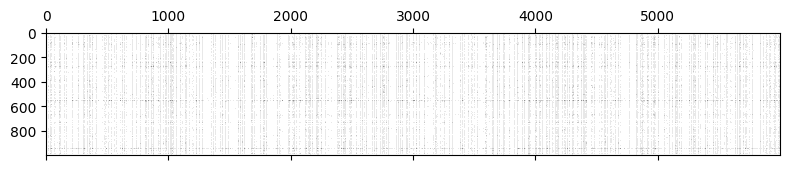

In [8]:
fig, ax = plt.subplots(figsize=(8,11))
cax = ax.matshow(np.array(E_mat.todense()), cmap='Greys')
plt.tight_layout()
plt.show()

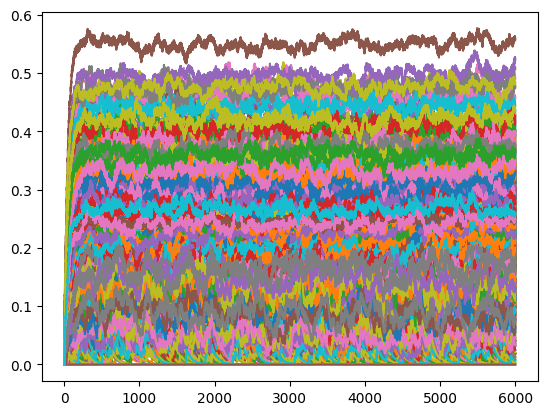

In [50]:
plt.plot(fmat.T)
plt.show()

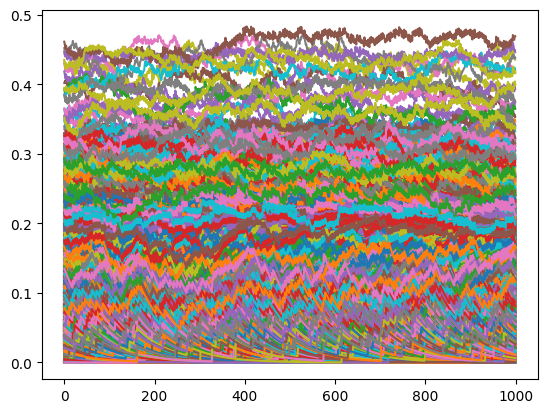

In [44]:
plt.plot(flu_l[0].T[1000:2000])
plt.show()

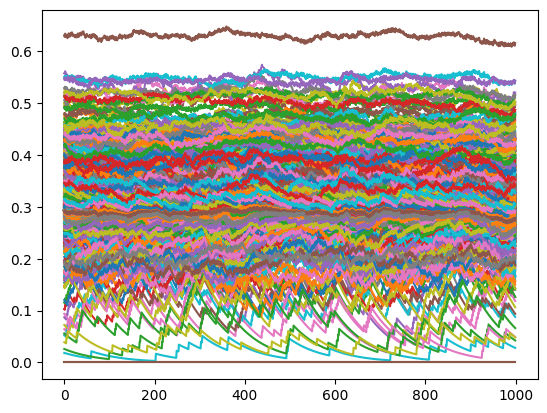

In [45]:
plt.plot(flu_l[3].T[1000:2000])
plt.show()

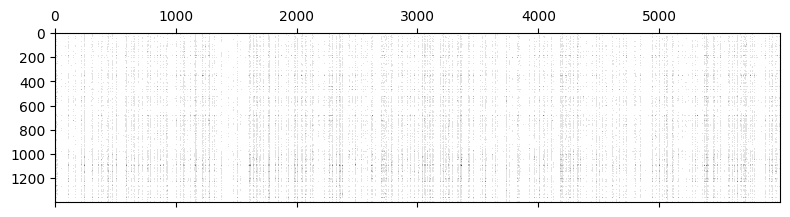

In [37]:
fig, ax = plt.subplots(figsize=(8,11))
cax = ax.matshow(np.array(data_l[0]), cmap='Greys')
plt.tight_layout()
plt.show()

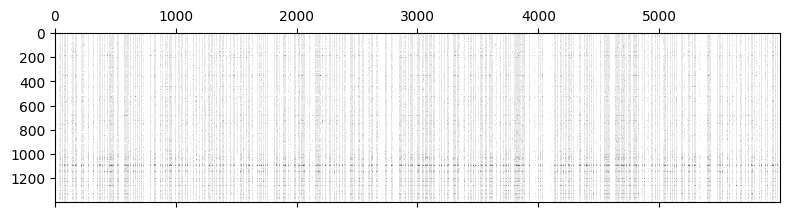

In [40]:
fig, ax = plt.subplots(figsize=(8,11))
cax = ax.matshow(np.array(data_l[3]), cmap='Greys')
plt.tight_layout()
plt.show()

In [10]:
mat.shape

(1400, 6000)

In [35]:
%%time
eew_vals = [3, 3.3, 3.7, 4.0]
pr_l = []
data_l = []
flu_l = []
for e in tqdm(eew_vals):
    _pars = pars.copy()
    _pars['e-e_synw_u'] = e
    
    E_mat, I_mat = _run(_pars)
    dt_native = 1/100.0
    mat = np.array(sp.vstack((E_mat, I_mat)).todense())
    fmat = spk_to_fl(S=mat, dt_native=1/100)
    PR, _ = participation_ratio(fmat)
    pr_l.append(PR)
    data_l.append(mat)
    flu_l.append(fmat)


100%|█████████████████████████████████████████████████████████████████| 4/4 [03:45<00:00, 56.31s/it]

CPU times: user 4min 23s, sys: 4.77 s, total: 4min 28s
Wall time: 3min 45s


In [10]:
#run
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

E_mat, I_mat = _run(_pars)
dt_native = 1/100.0
mat = np.array(sp.vstack((E_mat, I_mat)).todense())
fmat = spk_to_fl(S=mat, dt_native=1/100)

#estimate PR
PR, _ = participation_ratio(fmat)

#estimate E - for now use tau = 10 on top 10 PCs
X = fmat.T[200:]
sc = StandardScaler().fit_transform(X)
pca = PCA(n_components=10).fit_transform(sc)
out = E_from_pcs(pca)
E = np.mean(out[0])


In [11]:
PR, E

(2.487890395749784, 2.6)

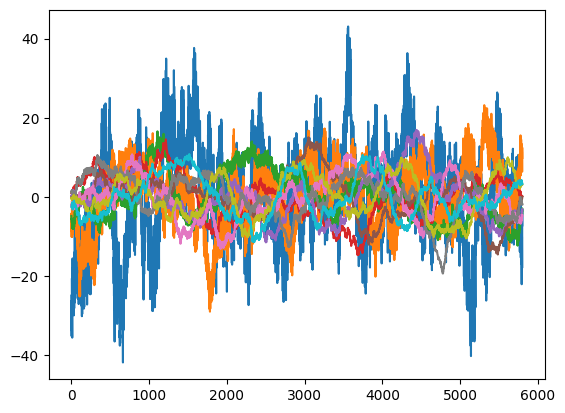

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
plt.plot(pca)
plt.show()

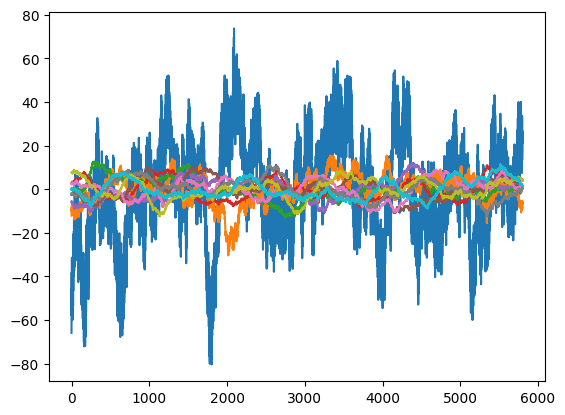

In [70]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
X = flu_l[3].T[200:]
sc = StandardScaler().fit_transform(X)
pca = PCA(n_components=10).fit_transform(sc)
plt.plot(pca)
plt.show()

In [12]:
import numpy as np
import pandas as pd
import itertools
import time
import scipy.sparse as sp
from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ======== Your functions ========
# Assumed to exist in your namespace:
#   _run(_pars)
#   spk_to_fl(S, dt_native)
#   participation_ratio(fmat)
#   E_from_pcs(pca)

# ===============================================================
# Base parameters
# ===============================================================
base_pars = {
    'spike_threshold_u': -50,
    'spike_threshold_sigma': 5,
    'rmp_u': -70,
    'rmp_sigma': 1,
    'synaptic_delay_u': 1.0,
    'synaptic_delay_sigma': 0.15,
    'tau_excitatory_u': 12,
    'tau_inhibitory_u': 6,
    'tau_sigma': 2,
    'refractory_excitatory_u': 2.0,
    'refractory_inhibitory_u': 1.0,
    'refractory_sigma': 0.5,
    'excitatory_size': 1000,
    'inhibitory_size': 400,
    'e-e_connectivity_p': 0.05,
    'e-i_connectivity_p': 0.08,
    'i-e_connectivity_p': 0.25,
    'i-i_connectivity_p': 0.20,
    'e-e_synw_u': 3.5,
    'e-i_synw_u': 1.9,
    'i-e_synw_u': 2.1,
    'i-i_synw_u': 1.7,
    'synw_sigma': 0.3,
    'PI_size': 1000,
    'PI_p': 0.1,
    'PI_rates_u_excitatory': 8,
    'PI_rates_u_inhibitory': 8,
    'PI_rates_sigma': 0.1,
    'PI_weights_sigma': 0.2,
    'PI_weights_u_excitatory': 1.0,
    'PI_weights_u_inhibitory': 1.0
}

# ===============================================================
# Parameters to vary and their ranges
# ===============================================================
param_grid = {
    'PI_rates_sigma':      np.linspace(0.05, 0.5, 10),
    'synw_sigma':          np.linspace(0.1, 1.0, 10),
    'e-e_connectivity_p':  np.linspace(0.02, 0.1, 10),
    'i-e_connectivity_p':  np.linspace(0.1, 0.4, 10),
    'e-i_connectivity_p':  np.linspace(0.04, 0.15, 10),
    'i-i_connectivity_p':  np.linspace(0.1, 0.3, 10),
    'synaptic_delay_u':    np.linspace(0.5, 2.0, 10),
    'tau_excitatory_u':    np.linspace(6, 20, 10),
    'tau_inhibitory_u':    np.linspace(3, 12, 10),
}

# ===============================================================
# Core evaluation function
# ===============================================================
def evaluate_param(param_name, value, base_pars):
    pars = base_pars.copy()
    pars[param_name] = value

    try:
        # ---- run network ----
        E_mat, I_mat = _run(pars)
        mat = np.array(sp.vstack((E_mat, I_mat)).todense())
        fmat = spk_to_fl(S=mat, dt_native=1/100)

        # ---- PR ----
        PR, _ = participation_ratio(fmat)

        # ---- E (embedding dimension) ----
        X = fmat.T[200:]
        sc = StandardScaler().fit_transform(X)
        pca = PCA(n_components=10).fit_transform(sc)
        out = E_from_pcs(pca)
        E_mean = np.mean(out['rho_vec']) if isinstance(out, dict) else np.mean(out[0])

        return {'param': param_name, 'value': value, 'PR': PR, 'E': E_mean}

    except Exception as e:
        print(f"Error on {param_name}={value}: {e}")
        return {'param': param_name, 'value': value, 'PR': np.nan, 'E': np.nan}

# ===============================================================
# Parallel grid search
# ===============================================================
def run_grid(param_grid, base_pars, n_jobs=4, save_csv='grid_results.csv'):
    tasks = []
    for param, values in param_grid.items():
        for v in values:
            tasks.append((param, v))

    print(f"Total runs: {len(tasks)}")
    t0 = time.time()

    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(evaluate_param)(p, v, base_pars) for p, v in tasks
    )

    df = pd.DataFrame(results)
    df.to_csv(save_csv, index=False)
    print(f"\nGrid complete. Saved to {save_csv}")
    print(f"Elapsed: {(time.time()-t0)/3600:.2f} hours")

    return df

# ===============================================================
# Run overnight grid search
# ===============================================================
if __name__ == "__main__":
    df = run_grid(param_grid, base_pars, n_jobs=4, save_csv='E_PR_grid_results.csv')
    print(df.head())


Total runs: 90


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
WARNING    Cannot use Cython, a test compilation failed: Cython is not available (ImportError)
Certain compiler configurations (e.g. clang in a conda environment on OS X) are known to be problematic. Note that you can switch the compiler by setting the 'CC' and 'CXX' environment variables. For example, you may want to try 'CC=gcc' and 'CXX=g++'. [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]
WARNING    Cannot use Cython, a test compilation failed: Cython is not available (ImportError)
Certain compiler configurations (e.g. clang in a conda environment on OS X) are known to be problematic. Note that you can switch 

In [ ]:
# identify mechaniss that separate out low PR -> high vs low E
# look in data -> explore more